## LoRA Inference for Stable Diffusion

This notebook loads a Stable Diffusion base model and your trained LoRA weights from `lora-output-jellyfish` to generate awareness photography images.

Run the cells from top to bottom after your LoRA training has finished.

In [31]:
import torch
from diffusers import StableDiffusionPipeline
from matplotlib import pyplot as plt

# Base Stable Diffusion model and LoRA weights directory
base_model = "runwayml/stable-diffusion-v1-5"
lora_dir = "/home/ament/Fine_tuning_stable_diffusion/lora-output-Jan-23-26/checkpoint-4500"

# Device and dtype
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Using device: {device}, dtype: {dtype}")

Using device: cuda, dtype: torch.float16


In [32]:
# Load base Stable Diffusion pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    base_model,
    torch_dtype=dtype,
)
pipe = pipe.to(device)

# Load your trained LoRA weights

pipe.load_lora_weights(lora_dir)

# Optionally fuse LoRA weights for faster inference (if supported)
try:
    pipe.fuse_lora(lora_scale=1.0)
    print("Fused LoRA weights with scale=1.0")
except AttributeError:
    print("Pipeline does not support fuse_lora; using default LoRA scaling.")

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 13.49it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Fused LoRA weights with scale=1.0


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:12<00:00,  8.13it/s]


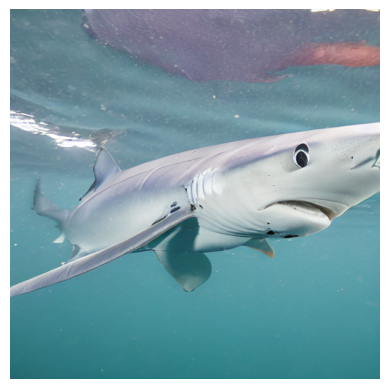

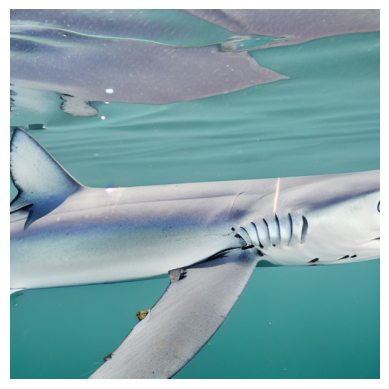

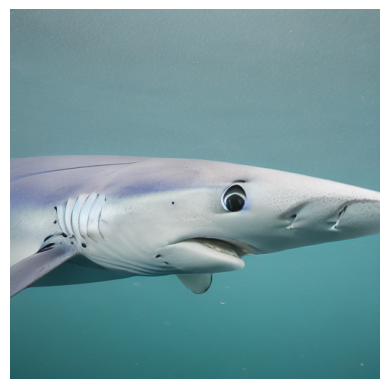

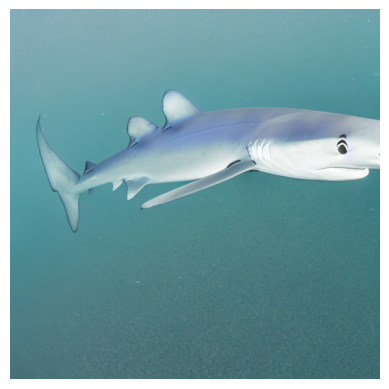

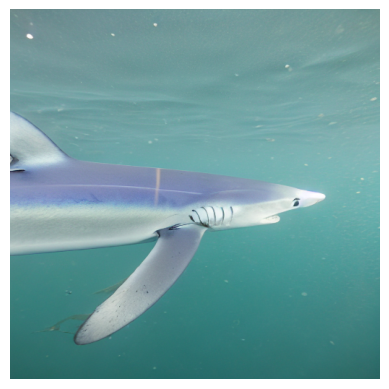

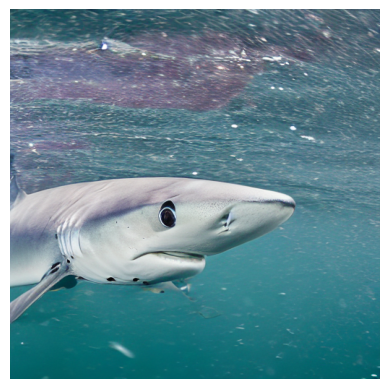

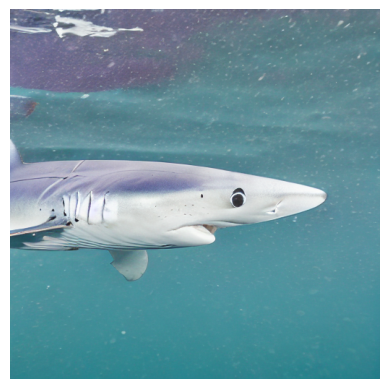

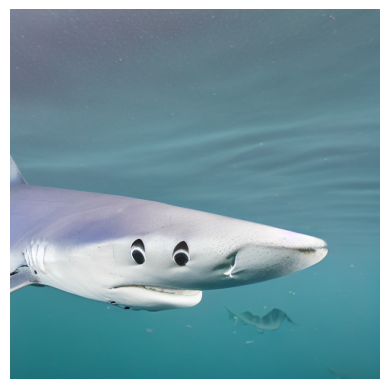

In [35]:
from datetime import datetime

# Prompt tuned to your dataset style
prompt = "A documentary style image of a blue shark swimming elegantly among the coral reefs in the deep ocean, soft lighting, photo realistic"
negative_prompt = None

#prompt = "A majestic lion's mane jellyfish, with many entangling tentacles, photo realistic."
#negative_prompt = "The sea surface, the sky, the horizon"

num_images = 8
num_inference_steps = 100
guidance_scale = 5
seed = None

# Set random seed for reproducibility
generator = torch.Generator(device=device)
if seed is not None:
    generator = generator.manual_seed(seed)

pipe.set_progress_bar_config(disable=False)

result = pipe(
    prompt=[prompt] * num_images,
    negative_prompt=[negative_prompt] * num_images if negative_prompt else None,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    resolution=512,
)

images = result.images

# Display the first image in the notebook
for i in range(num_images):
    plt.imshow(images[i])
    plt.axis('off')
    plt.show()

In [39]:
# Save all generated images to disk
import os

output_dir = "lora_inference_outputs_notebook"
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for i, img in enumerate(images):
    filename = os.path.join(output_dir, f"lora_notebook_space{timestamp}_{i:02d}.png")
    img.save(filename)
    print(f"Saved image {i} to: {filename}")

Saved image 0 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_00.png
Saved image 1 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_01.png
Saved image 2 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_02.png
Saved image 3 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_03.png
Saved image 4 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_04.png
Saved image 5 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_05.png
Saved image 6 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_06.png
Saved image 7 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_07.png
Saved image 8 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_08.png
Saved image 9 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_09.png
Saved image 10 to: lora_inference_outputs_notebook/lora_notebook_space20260121_2